<a href="https://colab.research.google.com/github/Khafidh10/KNA/blob/main-branch/Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
# ======================================
# 1. MOUNT GOOGLE DRIVE
# ======================================
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# ======================================
# 2. IMPORT LIBRARY
# ======================================
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

In [63]:
# ======================================
# 3. CEK FILE SHAPEFILE DI GOOGLE DRIVE
# ======================================
# Langkah ini untuk memastikan bahwa file .shp sudah terdeteksi dan berada di path yang benar
import os
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for name in files:
        if name.endswith(".shp"):
            print(os.path.join(root, name))


/content/drive/MyDrive/Pelatihan Geofisika/Geosoftware/Data/Processed_JKT/processed_jkt.shp
/content/drive/MyDrive/Peta Geologi/Geologi Struktur Indonesia/Geologi_Struktur.shp
/content/drive/MyDrive/Peta Geologi/GEOLOGI INA/Geologi_Struktur.shp
/content/drive/MyDrive/Peta Geologi/SHP_Admin_Indonesia/Kec1_region.shp
/content/drive/MyDrive/Peta Geologi/SHP_Admin_Indonesia/Kec2_region.shp
/content/drive/MyDrive/Peta Geologi/SHP_Admin_Indonesia/Desa1_polyline.shp
/content/drive/MyDrive/Peta Geologi/SHP_Admin_Indonesia/Desa1_region.shp
/content/drive/MyDrive/Peta Geologi/SHP_Admin_Indonesia/River_point.shp
/content/drive/MyDrive/Peta Geologi/SHP_Admin_Indonesia/Desa6_polyline.shp
/content/drive/MyDrive/Peta Geologi/SHP_Admin_Indonesia/Kab6_polyline.shp
/content/drive/MyDrive/Peta Geologi/SHP_Admin_Indonesia/River_polyline.shp
/content/drive/MyDrive/Peta Geologi/SHP_Admin_Indonesia/Desa3_polyline.shp
/content/drive/MyDrive/Peta Geologi/SHP_Admin_Indonesia/Kec6_polyline.shp
/content/drive/MyD

In [64]:
# ======================================
# 4. LOAD SHAPEFILE
# ======================================
# Load the shapefile into a GeoDataFrame
try:
    gdf = gpd.read_file("/content/drive/MyDrive/Pelatihan Geofisika/Geosoftware/Data/Processed_JKT/processed_jkt.shp")
    print("Shapefile loaded successfully.")
    print(gdf.head())
except Exception as e:
    print(f"Error loading shapefile: {e}")

Shapefile loaded successfully.
   OBJECT_ID   KODE_DESA            DESA      KODE     PROVINSI  \
0    25477.0  3173031006       KEAGUNGAN  317303.0  DKI JAKARTA   
1    25478.0  3173031007          GLODOK  317303.0  DKI JAKARTA   
2    25397.0  3171031003   HARAPAN MULIA  317103.0  DKI JAKARTA   
3    25400.0  3171031006    CEMPAKA BARU  317103.0  DKI JAKARTA   
4    25378.0  3101011001  PULAU PANGGANG  310101.0  DKI JAKARTA   

           KAB_KOTA               KECAMATAN      DESA_KELUR  JUMLAH_PEN  \
0     JAKARTA BARAT              TAMAN SARI       KEAGUNGAN     21609.0   
1     JAKARTA BARAT              TAMAN SARI          GLODOK      9069.0   
2     JAKARTA PUSAT               KEMAYORAN   HARAPAN MULIA     29085.0   
3     JAKARTA PUSAT               KEMAYORAN    CEMPAKA BARU     41913.0   
4  KEPULAUAN SERIBU  KEPULAUAN SERIBU UTARA  PULAU PANGGANG      6947.0   

   JUMLAH_KK  ...  luas_km2  keliling_k  kompaksi  jarak_ke_m    kepadata_1  \
0     7255.0  ...  0.353146    2.593

In [73]:
# ======================================
# 5. EKSPLORASI DATA (dengan cek variabel)
# ======================================
if 'gdf' in globals():
    print("Kolom yang tersedia:", gdf.columns)
    print("\nInfo Data:\n")
    print(gdf.info())
    print("\nStatistik Deskriptif:\n", gdf.describe())
    print("\nJumlah Missing Value:\n", gdf.isnull().sum())
else:
    print("❌ DataFrame 'gdf' belum terbaca. Pastikan shapefile berhasil di-load.")

Kolom yang tersedia: Index(['OBJECT_ID', 'KODE_DESA', 'DESA', 'KODE', 'PROVINSI', 'KAB_KOTA',
       'KECAMATAN', 'DESA_KELUR', 'JUMLAH_PEN', 'JUMLAH_KK', 'LUAS_WILAY',
       'KEPADATAN', 'PERPINDAHA', 'PERUBAHAN', 'WAJIB_KTP', 'ISLAM', 'KRISTEN',
       'KHATOLIK', 'HINDU', 'BUDHA', 'KONGHUCU', 'KEPERCAYAA', 'PRIA',
       'WANITA', 'BELUM_KAWI', 'KAWIN', 'BELUM_BEKE', 'GENERATED',
       'KODE_DES_1', 'LUAS_DESA', 'KODE_DES_3', 'DESA_KEL_1', 'KODE_12',
       'BEKERJA', 'USIA_PRODU', 'USIA_NON_P', 'P_RENDAH', 'P_TINGGI',
       'resiko_kre', 'luas_km2', 'keliling_k', 'kompaksi', 'jarak_ke_m',
       'kepadata_1', 'rasio_prod', 'rasio_pend', 'rasio_peng', 'resiko_k_1',
       'geometry'],
      dtype='object')

Info Data:

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 49 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECT_ID   267 non-null    float64 
 1   KODE_DESA   267 non-n

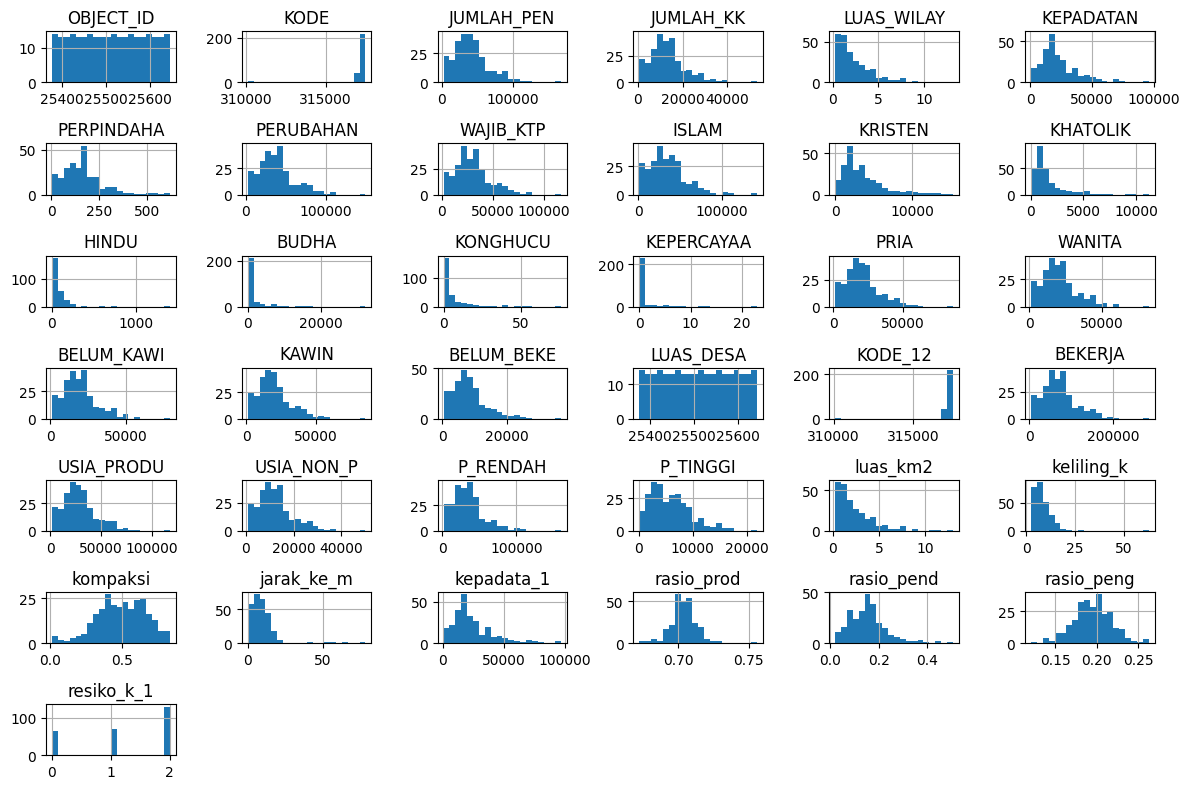

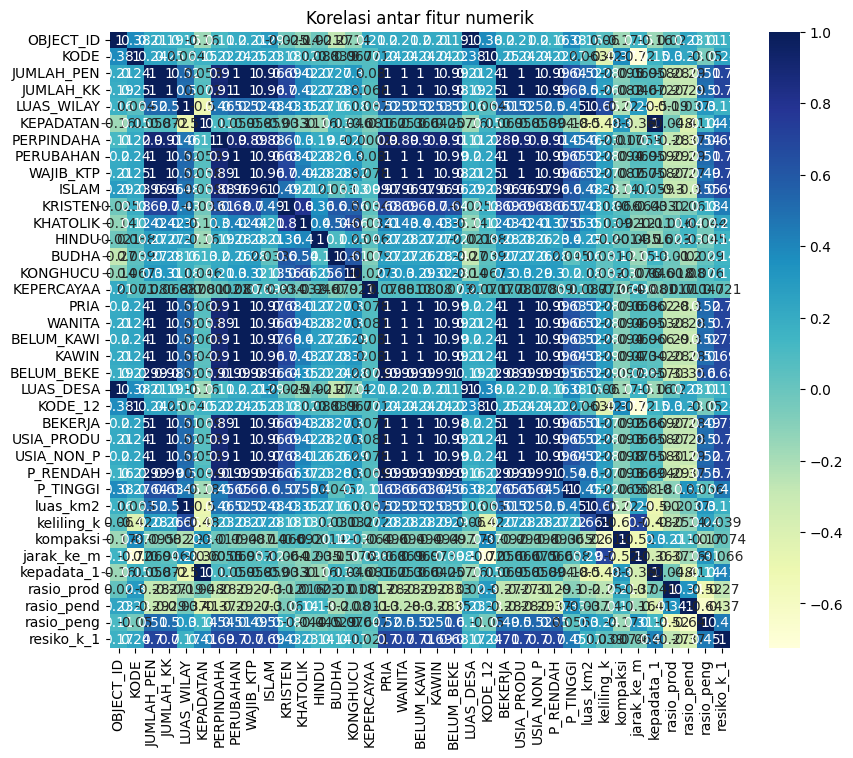

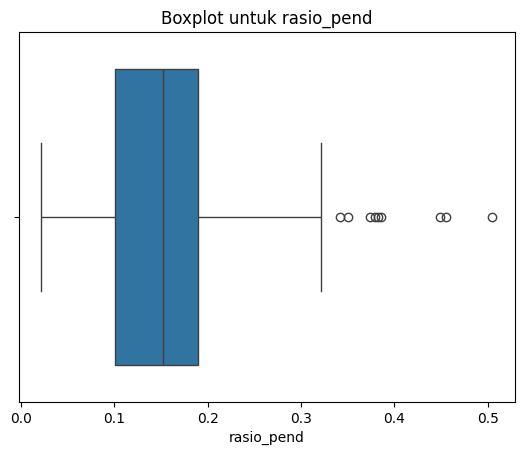

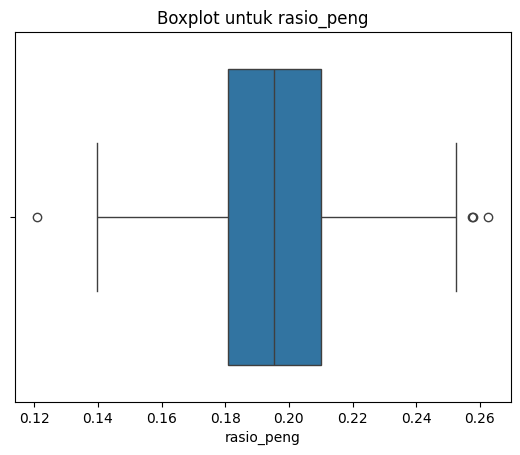

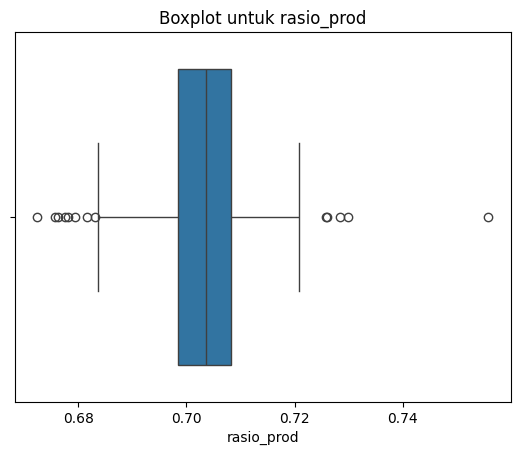

In [72]:
# ======================================
# 6. VISUALISASI DATA
# ======================================
# Histograms
gdf.hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(gdf.select_dtypes(include='number').corr(), annot=True, cmap="YlGnBu")
plt.title("Korelasi antar fitur numerik")
plt.show()

# (Tambahan opsional) Visualisasi sebaran: boxplot
for col in ['rasio_pend', 'rasio_peng', 'rasio_prod']:
    sns.boxplot(data=gdf, x=col)
    plt.title(f"Boxplot untuk {col}")
    plt.show()

In [67]:
# ======================================
# 7. PREPROCESSING
# ======================================
# Pilih fitur yang relevan (ganti sesuai nama kolom Anda)
features = ['rasio_pend', 'rasio_peng', 'rasio_prod']
target = 'resiko_k_1'

# Hapus baris dengan missing values
data = gdf[features + [target]].dropna()

# Encoding target jika belum numerik
data[target] = data[target].astype('category').cat.codes  # Misal: Low=0, Medium=1, High=2

# Split data
X = data[features]
y = data[target]

# Normalisasi (optional)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [68]:
# ======================================
# 8. TRAIN DECISION TREE
# ======================================
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [69]:
# ======================================
# 9. EVALUASI MODEL
# ======================================
y_pred = clf.predict(X_test)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[ 4  8  5]
 [ 6  9  6]
 [10 10 23]]

Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.24      0.22        17
           1       0.33      0.43      0.38        21
           2       0.68      0.53      0.60        43

    accuracy                           0.44        81
   macro avg       0.40      0.40      0.40        81
weighted avg       0.49      0.44      0.46        81



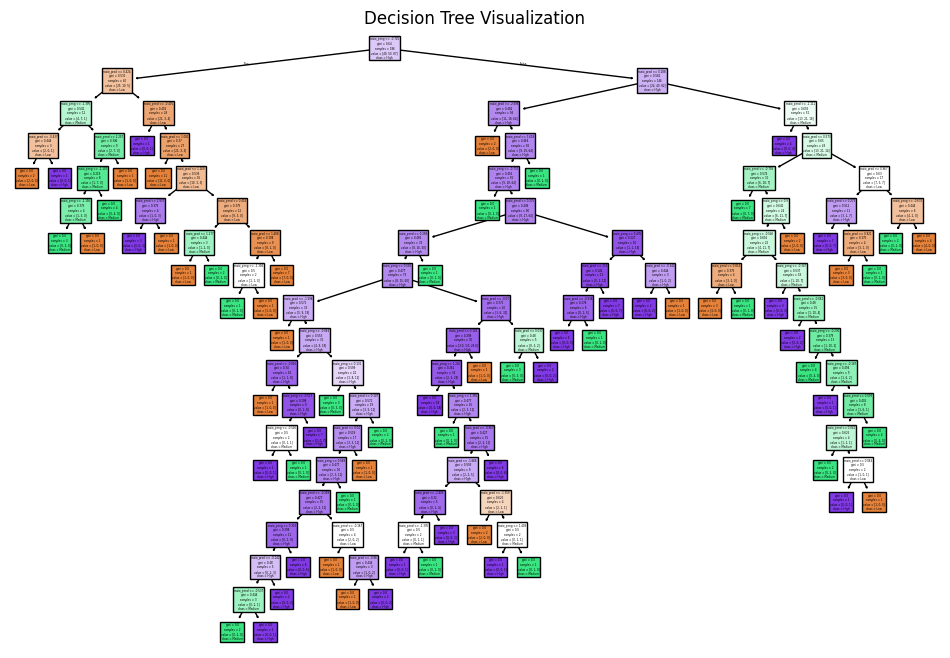

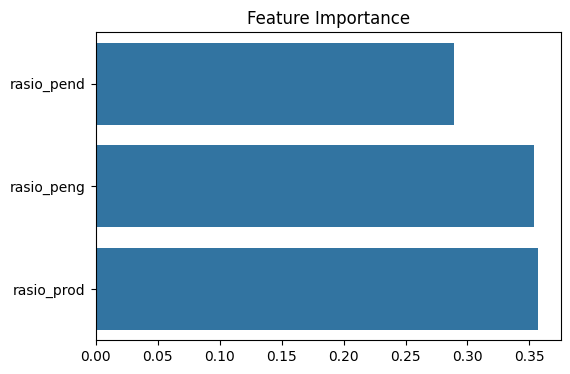

In [70]:
# ======================================
# 10. VISUALISASI PERFORMA DAN FEATURE IMPORTANCE
# ======================================
# Plot pohon keputusan
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=features, class_names=['Low', 'Medium', 'High'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

# Feature importance
importances = clf.feature_importances_
plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()



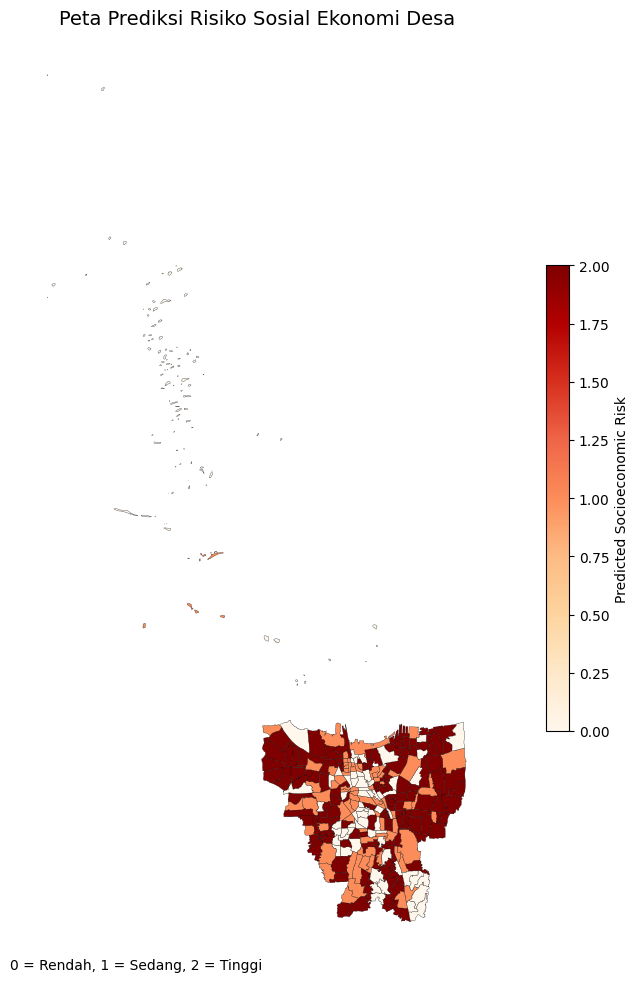

In [76]:
# ======================================
# 11. MENYIMPAN HASIL PREDIKSI (opsional)
# ======================================
gdf_pred = gdf.copy()
gdf_pred['predicted_risk'] = clf.predict(scaler.transform(gdf[features].fillna(0)))
# gdf_pred.to_file("hasil_prediksi.shp")  # jika ingin disimpan sebagai SHP



import matplotlib.pyplot as plt

# Buat figure dan axis agar lebih fleksibel
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot peta dengan legend yang proporsional
gdf_pred.plot(
    column='predicted_risk',
    cmap='OrRd',
    legend=True,
    legend_kwds={'shrink': 0.5, 'label': "Predicted Socioeconomic Risk"},
    ax=ax,
    edgecolor='black',
    linewidth=0.2
)

# Tambahkan keterangan manual
plt.figtext(0.5, 0.01, '0 = Rendah, 1 = Sedang, 2 = Tinggi', ha='center', fontsize=10)

# Tambahkan judul dan bersihkan axis
ax.set_title("Peta Prediksi Risiko Sosial Ekonomi Desa", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()




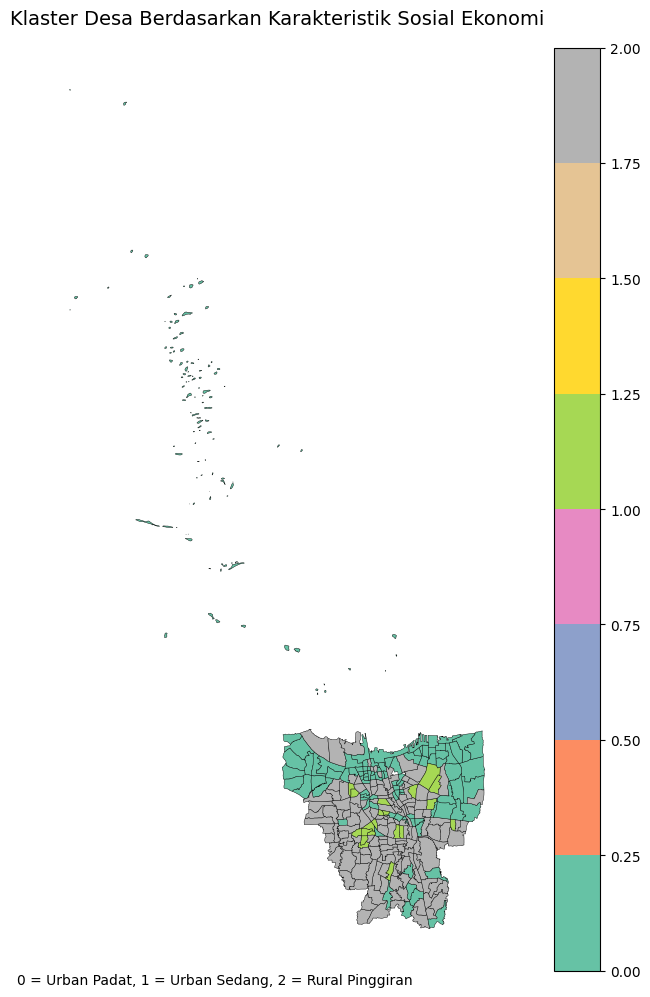

In [80]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Gunakan fitur yang ingin dikelompokkan
X_cluster = gdf[['rasio_pend', 'rasio_peng', 'rasio_prod']].dropna()

# Terapkan KMeans dengan 3 klaster (bisa disesuaikan)
kmeans = KMeans(n_clusters=3, random_state=42)
gdf.loc[X_cluster.index, 'cluster'] = kmeans.fit_predict(X_cluster)

# Visualisasi klaster desa
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column='cluster', cmap='Set2', legend=True, ax=ax, edgecolor='black', linewidth=0.3)
ax.set_title("Klaster Desa Berdasarkan Karakteristik Sosial Ekonomi", fontsize=14)
ax.axis('off')

# Tambahkan keterangan manual setelah plot dan sebelum show
plt.figtext(0.5, 0.01, '0 = Urban Padat, 1 = Urban Sedang, 2 = Rural Pinggiran', ha='center', fontsize=10)

plt.tight_layout()
plt.show()
